# COVID-19 Literature Clustering

### Loading Metadata

In [0]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import glob
import json

import matplotlib.pyplot as plt
plt.style.use('ggplot')

Let's load the metadata of the dateset. 'title' and 'journal' attributes may be useful later when we cluster the articles to see what kinds of articles cluster together.

In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

Go to this URL in a browser: https://accounts.google.com/o/oauth2/auth?client_id=947318989803-6bn6qk8qdgf4n4g3pfee6491hc0brc4i.apps.googleusercontent.com&redirect_uri=urn%3aietf%3awg%3aoauth%3a2.0%3aoob&response_type=code&scope=email%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdocs.test%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive.photos.readonly%20https%3a%2f%2fwww.googleapis.com%2fauth%2fpeopleapi.readonly

Enter your authorization code:
··········
Mounted at /content/gdrive


In [0]:
import os
os.environ['KAGGLE_CONFIG_DIR'] = "/content/gdrive/My Drive/Kaggle"

In [3]:
%cd /content/gdrive/My Drive/Kaggle

/content/gdrive/My Drive/Kaggle


In [0]:
!kaggle datasets download -d allen-institute-for-ai/CORD-19-research-challenge

CORD-19-research-challenge.zip: Skipping, found more recently modified local copy (use --force to force download)


In [4]:
!ls

arxiv				COVID.DATA.LIC.AGMT.pdf    metadata.readme
biorxiv_medrxiv			custom_license		   noncomm_use_subset
ClassSelect.filterd.utf8.csv	improved_cluster_tsne.png  test.txt
comm_use_subset			json_schema.txt		   t-sne_covid19.png
cord_19_embeddings_4_24		kaggle.json		   week3_neuSomatic.pdf
CORD-19-research-challenge.zip	metadata.csv


In [0]:
!unzip *.zip && rm *.zip

In [29]:
#root_path = '/kaggle/input/CORD-19-research-challenge/'
#metadata_path = f'{root_path}/metadata.csv'

metadata_path = 'new_meta.csv'

meta_df = pd.read_csv(metadata_path, dtype={
    'pubmed_id': str,
    'Microsoft Academic Paper ID': str, 
    'doi': str
})
#meta_df.head()

/usr/local/lib/python3.6/dist-packages/IPython/core/interactiveshell.py:2718: DtypeWarning: Columns (14,15,16) have mixed types.Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)


### Fetch All of JSON File Path

Get path to all JSON files:

In [10]:
all_json = glob.glob('/content/gdrive/My Drive/Kaggle/arxiv/**/*.json', recursive=True)
len(all_json)

16914

In [0]:
all_json[1]

'/content/gdrive/My Drive/Kaggle/arxiv/arxiv/pdf_json/00c386ee8b9fac7eeb2291a72d52966d83eec814.json'

### Helper Functions

 File Reader Class

In [11]:
class FileReader:
    def __init__(self, file_path):
        with open(file_path) as file:
            content = json.load(file)
            self.paper_id = content['paper_id']
            self.abstract = []
            self.body_text = []
            # Abstract
            for entry in content['abstract']:
                self.abstract.append(entry['text'])
            # Body text
            for entry in content['body_text']:
                self.body_text.append(entry['text'])
            self.abstract = '\n'.join(self.abstract)
            self.body_text = '\n'.join(self.body_text)
    def __repr__(self):
        return f'{self.paper_id}: {self.abstract[:200]}... {self.body_text[:200]}...'
first_row = FileReader(all_json[0])
print(first_row)

00c386ee8b9fac7eeb2291a72d52966d83eec814: It is shown that the evaporation rate of a liquid sample containing the culture of coronavirus affects its survival on a substrate. Possible mechanisms of such influence can be due to the appearance o... It is shown that the evaporation rate of a liquid sample containing the culture of coronavirus affects its survival on a substrate. Possible mechanisms of such influence can be due to the appearance o...


Helper function adds break after every words when character length reach to certain amount. This is for the interactive plot so that hover tool fits the screen.

In [0]:
def get_breaks(content, length):
    data = ""
    words = content.split(' ')
    total_chars = 0

    # add break every length characters
    for i in range(len(words)):
        total_chars += len(words[i])
        if total_chars > length:
            data = data + "<br>" + words[i]
            total_chars = 0
        else:
            data = data + " " + words[i]
    return data

In [30]:
meta_df.loc[meta_df['sha'] == '95b96e2e-b2e0-4f2c-8345-72926bf336e7']

,cord_uid,sha,source_x,title,doi,pmcid,pubmed_id,license,abstract,publish_time,authors,journal,Microsoft Academic Paper ID,WHO #Covidence,arxiv_id,has_pdf_parse,has_pmc_xml_parse,full_text_file,url
59887,NaN,95b96e2e-b2e0-4f2c-8345-72926bf336e7,NaN,Clinical Applications of Polymeric Micelle Car...,10.1016/j.jecm.2011.06.002,NaN,NaN,NaN,NaN,NaN,Masayuki Yokoyama,Journal of Experimental and Clinical Medicine,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [31]:
meta_df.loc[meta_df['sha'] == '1b499bed-4ce8-4c0c-b682-0d58baae1cbe']

,cord_uid,sha,source_x,title,doi,pmcid,pubmed_id,license,abstract,publish_time,authors,journal,Microsoft Academic Paper ID,WHO #Covidence,arxiv_id,has_pdf_parse,has_pmc_xml_parse,full_text_file,url
59888,NaN,1b499bed-4ce8-4c0c-b682-0d58baae1cbe,NaN,Cancer diagnosis in histopathological image: C...,10.1016/j.imu.2019.100231,NaN,NaN,NaN,NaN,NaN,Sumaiya Dabeer,Informatics in Medicine Unlocked,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Load the Data into DataFrame

Using the helper functions, let's read in the articles into a DataFrame that can be used easily:

In [32]:
dict_ = {'paper_id': [], 'doi':[], 'abstract': [], 'body_text': [], 'authors': [], 'title': [], 'journal': [], 'abstract_summary': []}
for idx, entry in enumerate(all_json):
    if idx % (len(all_json) // 10) == 0:
        print(f'Processing index: {idx} of {len(all_json)}')
    
    try:
        content = FileReader(entry)
    except Exception as e:
        continue  # invalid paper format, skip
    
    # get metadata information
    meta_data = meta_df.loc[meta_df['sha'] == content.paper_id]
    # no metadata, skip this paper
    if len(meta_data) == 0:
        continue
    
    dict_['abstract'].append(content.abstract)
    dict_['paper_id'].append(content.paper_id)
    dict_['body_text'].append(content.body_text)
    
    # also create a column for the summary of abstract to be used in a plot
    if len(content.abstract) == 0: 
        # no abstract provided
        dict_['abstract_summary'].append("Not provided.")
    elif len(content.abstract.split(' ')) > 100:
        # abstract provided is too long for plot, take first 100 words append with ...
        info = content.abstract.split(' ')[:100]
        summary = get_breaks(' '.join(info), 40)
        dict_['abstract_summary'].append(summary + "...")
    else:
        # abstract is short enough
        summary = get_breaks(content.abstract, 40)
        dict_['abstract_summary'].append(summary)
        
    # get metadata information
    meta_data = meta_df.loc[meta_df['sha'] == content.paper_id]
    
    try:
        # if more than one author
        authors = meta_data['authors'].values[0].split(';')
        if len(authors) > 2:
            # if more than 2 authors, take them all with html tag breaks in between
            dict_['authors'].append(get_breaks('. '.join(authors), 40))
        else:
            # authors will fit in plot
            dict_['authors'].append(". ".join(authors))
    except Exception as e:
        # if only one author - or Null valie
        dict_['authors'].append(meta_data['authors'].values[0])
    
    # add the title information, add breaks when needed
    try:
        title = get_breaks(meta_data['title'].values[0], 40)
        dict_['title'].append(title)
    # if title was not provided
    except Exception as e:
        dict_['title'].append(meta_data['title'].values[0])
    
    # add the journal information
    dict_['journal'].append(meta_data['journal'].values[0])
    
    # add doi
    dict_['doi'].append(meta_data['doi'].values[0])
    
df_covid = pd.DataFrame(dict_, columns=['paper_id', 'doi', 'abstract', 'body_text', 'authors', 'title', 'journal', 'abstract_summary'])
df_covid.head()

Processing index: 0 of 16914
Processing index: 1691 of 16914
Processing index: 3382 of 16914
Processing index: 5073 of 16914
Processing index: 6764 of 16914
Processing index: 8455 of 16914
Processing index: 10146 of 16914
Processing index: 11837 of 16914
Processing index: 13528 of 16914
Processing index: 15219 of 16914
Processing index: 16910 of 16914


,paper_id,doi,abstract,body_text,authors,title,journal,abstract_summary
0,00c386ee8b9fac7eeb2291a72d52966d83eec814,NaN,It is shown that the evaporation rate of a liq...,It is shown that the evaporation rate of a liq...,P. Grinchuk S.. E. Fisenko I.. S. Fisenko P...,Isothermal evaporation rate of deposited<br>l...,NaN,It is shown that the evaporation rate of a li...
1,024b30561568979f525d8b2580f85122c02008a0,NaN,A model of reactive social distancing in epide...,Let the proportions of a population who are su...,Rose Baker,Reactive Social distancing in a SIR model of<...,NaN,A model of reactive social distancing in<br>e...
2,003d2e515e1aaf06f0052769953e861ed8e56608,NaN,,"It is highly contagious, and severe cases can ...",Shaoping Hu. Yuan Gao. Zhangming Niu. Ying...,Weakly Supervised Deep Learning for COVID-19<...,NaN,Not provided.
3,00a407540a8bdd6d7425bd8a561eb21d69682511,NaN,Rapidly developed AI-based automated CT image ...,• For Coronavirus patients the system outputs ...,Ophir Gozes. Maayan Frid-Adar. Hayit<br>Gre...,Rapid AI Development Cycle for the Coronaviru...,NaN,Rapidly developed AI-based automated CT image...
4,02b3c0c87a6b32d5107a6e05f83f73cb7f939432,NaN,Large scale disease screening is a complicated...,In many cohort studies specimens collected fro...,Gregory Haber. Yaakov Malinovsky. Paul Albe...,Is Group Testing Ready for Prime-time in<br>D...,NaN,Large scale disease screening is a complicate...


In [33]:
df_covid.loc[df_covid['paper_id'] == '95b96e2e-b2e0-4f2c-8345-72926bf336e7']

,paper_id,doi,abstract,body_text,authors,title,journal,abstract_summary
748,95b96e2e-b2e0-4f2c-8345-72926bf336e7,10.1016/j.jecm.2011.06.002,Polymeric micelles are assemblies of synthetic...,1. Polymeric Micelles as Nano-sized Drug Carri...,Masayuki Yokoyama,Clinical Applications of Polymeric Micelle<br...,Journal of Experimental and Clinical Medicine,Polymeric micelles are assemblies of<br>synth...


In [34]:
df_covid.loc[df_covid['paper_id'] == '1b499bed-4ce8-4c0c-b682-0d58baae1cbe']

,paper_id,doi,abstract,body_text,authors,title,journal,abstract_summary
747,1b499bed-4ce8-4c0c-b682-0d58baae1cbe,10.1016/j.imu.2019.100231,Breast cancer affects one out of eight females...,1. Introduction \n\n\n\nAmong all types of can...,Sumaiya Dabeer,Cancer diagnosis in histopathological image:<...,Informatics in Medicine Unlocked,Breast cancer affects one out of eight female...


## Some feature engineering
Adding word count columns for both abstract and body_text can be useful parameters later:

In [35]:
df_covid['abstract_word_count'] = df_covid['abstract'].apply(lambda x: len(x.strip().split()))  # word count in abstract
df_covid['body_word_count'] = df_covid['body_text'].apply(lambda x: len(x.strip().split()))  # word count in body
df_covid['body_unique_words']=df_covid['body_text'].apply(lambda x:len(set(str(x).split())))  # number of unique words in body
df_covid.head()

,paper_id,doi,abstract,body_text,authors,title,journal,abstract_summary,abstract_word_count,body_word_count,body_unique_words
0,00c386ee8b9fac7eeb2291a72d52966d83eec814,NaN,It is shown that the evaporation rate of a liq...,It is shown that the evaporation rate of a liq...,P. Grinchuk S.. E. Fisenko I.. S. Fisenko P...,Isothermal evaporation rate of deposited<br>l...,NaN,It is shown that the evaporation rate of a li...,119,3140,943
1,024b30561568979f525d8b2580f85122c02008a0,NaN,A model of reactive social distancing in epide...,Let the proportions of a population who are su...,Rose Baker,Reactive Social distancing in a SIR model of<...,NaN,A model of reactive social distancing in<br>e...,53,952,426
2,003d2e515e1aaf06f0052769953e861ed8e56608,NaN,,"It is highly contagious, and severe cases can ...",Shaoping Hu. Yuan Gao. Zhangming Niu. Ying...,Weakly Supervised Deep Learning for COVID-19<...,NaN,Not provided.,0,4007,1408
3,00a407540a8bdd6d7425bd8a561eb21d69682511,NaN,Rapidly developed AI-based automated CT image ...,• For Coronavirus patients the system outputs ...,Ophir Gozes. Maayan Frid-Adar. Hayit<br>Gre...,Rapid AI Development Cycle for the Coronaviru...,NaN,Rapidly developed AI-based automated CT image...,102,2060,819
4,02b3c0c87a6b32d5107a6e05f83f73cb7f939432,NaN,Large scale disease screening is a complicated...,In many cohort studies specimens collected fro...,Gregory Haber. Yaakov Malinovsky. Paul Albe...,Is Group Testing Ready for Prime-time in<br>D...,NaN,Large scale disease screening is a complicate...,1255,4439,1121


In [19]:
df_covid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5311 entries, 0 to 5310
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   paper_id             5311 non-null   object
 1   doi                  4444 non-null   object
 2   abstract             5311 non-null   object
 3   body_text            5311 non-null   object
 4   authors              5197 non-null   object
 5   title                5311 non-null   object
 6   journal              1889 non-null   object
 7   abstract_summary     5311 non-null   object
 8   abstract_word_count  5311 non-null   int64 
 9   body_word_count      5311 non-null   int64 
 10  body_unique_words    5311 non-null   int64 
dtypes: int64(3), object(8)
memory usage: 456.5+ KB


In [0]:
df_covid['abstract'].describe(include='all')

count     747
unique    702
top          
freq       46
Name: abstract, dtype: object

## Handle Possible Duplicates

When we look at the unique values above, we can see that tehre are duplicates. It may have caused because of author submiting the article to multiple journals. Let's remove the duplicats from our dataset:

(Thank you Desmond Yeoh for recommending the below approach on Kaggle)

In [36]:
df_covid.drop_duplicates(['abstract', 'body_text'], inplace=True)
df_covid['abstract'].describe(include='all')

count     5311
unique    4393
top           
freq       890
Name: abstract, dtype: object

In [0]:
df_covid['body_text'].describe(include='all')

count                                                   747
unique                                                  747
top       According to a tally by Johns Hopkins Universi...
freq                                                      1
Name: body_text, dtype: object

It looks like we didn't have duplicates. Instead, it was articles without Abstracts.

## Take a Look at the Data:

In [0]:
df_covid.describe()

,abstract_word_count,body_word_count,body_unique_words
count,747.000000,747.000000,747.000000
mean,195.912985,3827.251673,1137.364123
std,207.296466,2585.832982,528.323253
min,0.000000,7.000000,7.000000
25%,119.000000,2089.000000,765.500000
50%,172.000000,3383.000000,1085.000000
75%,233.000000,4691.000000,1390.000000
max,3004.000000,30866.000000,5638.000000


# Data Pre-processing

Unfortunately, running the next steps of the notebook is not possible on the full dataset within Kaggle. The full plot is available is at https://maksimekin.github.io/COVID19-Literature-Clustering/plots/t-sne_covid-19_interactive.html.

In Kaggle we will limit the dataframe to **10,000** instances

In [0]:
#df = df_covid.sample(10000, random_state)
df = df_covid.copy()

Now that we have our dataset loaded, we need to clean-up the text to improve any clustering or classification efforts. First, let's drop Null vales:

In [38]:
df.dropna(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1711 entries, 103 to 5310
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   paper_id             1711 non-null   object
 1   doi                  1711 non-null   object
 2   abstract             1711 non-null   object
 3   body_text            1711 non-null   object
 4   authors              1711 non-null   object
 5   title                1711 non-null   object
 6   journal              1711 non-null   object
 7   abstract_summary     1711 non-null   object
 8   abstract_word_count  1711 non-null   int64 
 9   body_word_count      1711 non-null   int64 
 10  body_unique_words    1711 non-null   int64 
dtypes: int64(3), object(8)
memory usage: 160.4+ KB


In [46]:
df.loc[df['paper_id'] == '1b499bed-4ce8-4c0c-b682-0d58baae1cbe']

,paper_id,doi,abstract,body_text,authors,title,journal,abstract_summary,abstract_word_count,body_word_count,body_unique_words,language
747,1b499bed-4ce8-4c0c-b682-0d58baae1cbe,10.1016/j.imu.2019.100231,Breast cancer affects one out of eight females...,1. Introduction \n\n\n\nAmong all types of can...,Sumaiya Dabeer,Cancer diagnosis in histopathological image:<...,Informatics in Medicine Unlocked,Breast cancer affects one out of eight female...,155,3722,1418,en


In [47]:
df.loc[df['paper_id'] == '95b96e2e-b2e0-4f2c-8345-72926bf336e7']

,paper_id,doi,abstract,body_text,authors,title,journal,abstract_summary,abstract_word_count,body_word_count,body_unique_words,language
748,95b96e2e-b2e0-4f2c-8345-72926bf336e7,10.1016/j.jecm.2011.06.002,Polymeric micelles are assemblies of synthetic...,1. Polymeric Micelles as Nano-sized Drug Carri...,Masayuki Yokoyama,Clinical Applications of Polymeric Micelle<br...,Journal of Experimental and Clinical Medicine,Polymeric micelles are assemblies of<br>synth...,82,5609,1676,en


### Handling multiple languages
Next we are going to determine the language of each paper in the dataframe. Not all of the sources are English and the language needs to be identified so that we know how handle these instances

In [41]:
!pip install langdetect

     |████████████████████████████████| 983kB 9.4MB/s 
  Created wheel for langdetect: filename=langdetect-1.0.8-cp36-none-any.whl size=993193 sha256=c3fbe59e857c7b561247135d97edc307bba36ed35b7b61426fe9765fbe611083
  Stored in directory: /root/.cache/pip/wheels/8d/b3/aa/6d99de9f3841d7d3d40a60ea06e6d669e8e5012e6c8b947a57
Successfully built langdetect


In [42]:
from tqdm import tqdm
from langdetect import detect
from langdetect import DetectorFactory

# set seed
DetectorFactory.seed = 0

# hold label - language
languages = []

# go through each text
for ii in tqdm(range(0,len(df))):
    # split by space into list, take the first x intex, join with space
    text = df.iloc[ii]['body_text'].split(" ")
    
    lang = "en"
    try:
        if len(text) > 50:
            lang = detect(" ".join(text[:50]))
        elif len(text) > 0:
            lang = detect(" ".join(text[:len(text)]))
    # ught... beginning of the document was not in a good format
    except Exception as e:
        all_words = set(text)
        try:
            lang = detect(" ".join(all_words))
        # what!! :( let's see if we can find any text in abstract...
        except Exception as e:
            
            try:
                # let's try to label it through the abstract then
                lang = detect(df.iloc[ii]['abstract_summary'])
            except Exception as e:
                lang = "unknown"
                pass
    
    # get the language    
    languages.append(lang)

100%|██████████| 1711/1711 [00:08<00:00, 195.92it/s]


In [43]:
from pprint import pprint

languages_dict = {}
for lang in set(languages):
    languages_dict[lang] = languages.count(lang)
    
print("Total: {}\n".format(len(languages)))
pprint(languages_dict)

Total: 1711

{'af': 1, 'cy': 1, 'en': 1705, 'es': 1, 'pt': 2, 'zh-cn': 1}


Lets take a look at the language distribution in the dataset

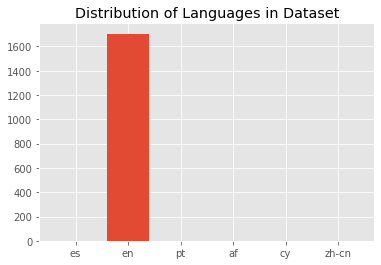

In [44]:
df['language'] = languages
plt.bar(range(len(languages_dict)), list(languages_dict.values()), align='center')
plt.xticks(range(len(languages_dict)), list(languages_dict.keys()))
plt.title("Distribution of Languages in Dataset")
plt.show()


We will be dropping any language that is not English. Attempting to translate foreign texts gave the following problems:

1. API calls were limited

2. Translating the language may not carry over the true semantic meaning of the text


In [45]:
df = df[df['language'] == 'en'] 
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1705 entries, 103 to 5310
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   paper_id             1705 non-null   object
 1   doi                  1705 non-null   object
 2   abstract             1705 non-null   object
 3   body_text            1705 non-null   object
 4   authors              1705 non-null   object
 5   title                1705 non-null   object
 6   journal              1705 non-null   object
 7   abstract_summary     1705 non-null   object
 8   abstract_word_count  1705 non-null   int64 
 9   body_word_count      1705 non-null   int64 
 10  body_unique_words    1705 non-null   int64 
 11  language             1705 non-null   object
dtypes: int64(3), object(9)
memory usage: 173.2+ KB


In [0]:
# Download the spacy bio parser

from IPython.utils import io
#with io.capture_output() as captured:
 #   !pip install https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.2.4/en_core_sci_lg-0.2.4.tar.gz

In [0]:
!pip install https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.2.4/en_core_sci_lg-0.2.4.tar.gz

In [0]:
#NLP 
import spacy
from spacy.lang.en.stop_words import STOP_WORDS
import en_core_sci_lg  # model downloaded in previous step

### Stopwords

Part of the preprocessing will be finding and removing stopwords (common words that will act as noise in the clustering step).

In [51]:
import string

punctuations = string.punctuation
stopwords = list(STOP_WORDS)
stopwords[:10]

['take',
 'cannot',
 'mine',
 'onto',
 'except',
 'put',
 'whose',
 'out',
 'seeming',
 'yourself']

Now the above stopwords are used in everyday english text. Research papers will often frequently use words that don't actually contribute to the meaning and are not considered everyday stopwords.

Thank you Daniel Wolffram for the idea.
#### Cite: [Custom Stop Words | Topic Modeling: Finding Related Articles](https://www.kaggle.com/danielwolffram/topic-modeling-finding-related-articles)

In [0]:
custom_stop_words = [
    'doi', 'preprint', 'copyright', 'peer', 'reviewed', 'org', 'https', 'et', 'al', 'author', 'figure', 
    'rights', 'reserved', 'permission', 'used', 'using', 'biorxiv', 'medrxiv', 'license', 'fig', 'fig.', 
    'al.', 'Elsevier', 'PMC', 'CZI', 'www'
]

for w in custom_stop_words:
    if w not in stopwords:
        stopwords.append(w)

### Next lets create a function that will process the text data for us. 
For this purpose we will be using the spacy library. This function will convert text to lower case, remove punctuation, and find and remove stopwords. For the parser, we will use en_core_sci_lg. This is a model for processing biomedical, scientific or clinical text.

In [0]:
# Parser
parser = en_core_sci_lg.load(disable=["tagger", "ner"])
parser.max_length = 7000000

def spacy_tokenizer(sentence):
    mytokens = parser(sentence)
    mytokens = [ word.lemma_.lower().strip() if word.lemma_ != "-PRON-" else word.lower_ for word in mytokens ]
    mytokens = [ word for word in mytokens if word not in stopwords and word not in punctuations ]
    mytokens = " ".join([i for i in mytokens])
    return mytokens

Applying the text-processing function on the **body_text**. 

In [54]:
tqdm.pandas()
df["processed_text"] = df["body_text"].progress_apply(spacy_tokenizer)

100%|██████████| 1705/1705 [08:42<00:00,  3.27it/s]


### Let's take a look at word count in the papers

In [55]:
import seaborn as sns

/usr/local/lib/python3.6/dist-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


count     1705.000000
mean      3600.697947
std       3112.109724
min         76.000000
25%       1983.000000
50%       3039.000000
75%       4606.000000
max      67920.000000
Name: body_word_count, dtype: float64

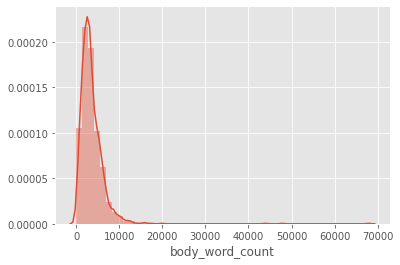

In [56]:
sns.distplot(df['body_word_count'])
df['body_word_count'].describe()

count     1705.000000
mean      1201.110850
std        669.235401
min         64.000000
25%        805.000000
50%       1085.000000
75%       1500.000000
max      11569.000000
Name: body_unique_words, dtype: float64

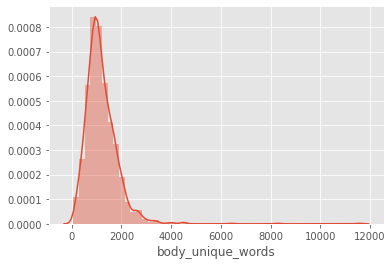

In [57]:
sns.distplot(df['body_unique_words'])
df['body_unique_words'].describe()

These two plots give us a good idea of the content we are dealing with. Most papers are about 5000 words in length. The long tails in both plots are caused by outliers. In fact, ~98% of the papers are under 20,000 words in length while a select few are over 200,000! <br><br>

# Vectorization

Now that we have pre-processed the data, it is time to convert it into a format that can be handled by our algorithms. For this purpose we will be using tf-idf. This will convert our string formatted data into a measure of how important each word is to the instance out of the literature as a whole.

In [0]:
from sklearn.feature_extraction.text import TfidfVectorizer
def vectorize(text, maxx_features):
    
    vectorizer = TfidfVectorizer(max_features=maxx_features)
    X = vectorizer.fit_transform(text)
    return X

Vectorize our data. We will be clustering based off the content of the body text. The maximum number of features will be limited. Only the top 2 ** 12 features will be used, eseentially acting as a noise filter. Additionally, more features cause painfully long runtimes.

In [59]:
text = df['processed_text'].values
X = vectorize(text, 2 ** 12)
X.shape

(1705, 4096)

# PCA  & Clustering

Let's see how much we can reduce the dimensions while still keeping 95% variance. We will apply Principle Component Analysis (PCA) to our vectorized data. The reason for this is that by keeping a large number of dimensions with PCA, you don’t destroy much of the information, but hopefully will remove some noise/outliers from the data, and make the clustering problem easier for k-means. Note that X_reduced will only be used for k-means, t-SNE will still use the original feature vector X that was generated through tf-idf on the NLP processed text.

(Thank you Dr. Edward Raff for the suggestion)

In [60]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95, random_state=42)
X_reduced= pca.fit_transform(X.toarray())
X_reduced.shape

(1705, 1063)

To separate the literature, k-means will be run on the vectorized text. Given the number of clusters, k, k-means will categorize each vector by taking the mean distance to a randomly initialized centroid. The centroids are updated iteratively.

In [0]:
from sklearn.cluster import KMeans

In [0]:
Image(filename='/kaggle/input/kaggle-resources/kmeans.PNG', width=800, height=800)

[source](https://en.wikipedia.org/wiki/K-means_clustering)

### How many clusters? 

To find the best k value for k-means we'll look at the distortion at different k values. Distortion computes the sum of squared distances from each point to its assigned center. When distortion is plotted against k there will be a k value after which decreases in distortion are minimal. This is the desired number of clusters.

In [0]:
from sklearn import metrics
from scipy.spatial.distance import cdist

# run kmeans with many different k
distortions = []
K = range(2, 20)
for k in K:
    k_means = KMeans(n_clusters=k, random_state=42).fit(X_reduced)
    k_means.fit(X_reduced)
    distortions.append(sum(np.min(cdist(X_reduced, k_means.cluster_centers_, 'euclidean'), axis=1)) / X.shape[0])
    #print('Found distortion for {} clusters'.format(k))

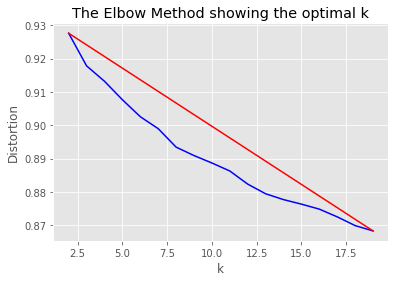

In [63]:
X_line = [K[0], K[-1]]
Y_line = [distortions[0], distortions[-1]]

# Plot the elbow
plt.plot(K, distortions, 'b-')
plt.plot(X_line, Y_line, 'r')
plt.xlabel('k')
plt.ylabel('Distortion')
plt.title('The Elbow Method showing the optimal k')
plt.show()

In this plot we can see that the better k values are between 18-25. After that, the decrease in distortion is not as significant. For simplicity, we will use k=20

### Run k-means

Now that we have an appropriate k value, we can run k-means on the PCA-processed feature vector (X_reduced). 

In [0]:
k = 8
kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(X_reduced)
df['y'] = y_pred

In [0]:
df

In [66]:
df.loc[df['paper_id'] == '95b96e2e-b2e0-4f2c-8345-72926bf336e7']

,paper_id,doi,abstract,body_text,authors,title,journal,abstract_summary,abstract_word_count,body_word_count,body_unique_words,language,processed_text,y
748,95b96e2e-b2e0-4f2c-8345-72926bf336e7,10.1016/j.jecm.2011.06.002,Polymeric micelles are assemblies of synthetic...,1. Polymeric Micelles as Nano-sized Drug Carri...,Masayuki Yokoyama,Clinical Applications of Polymeric Micelle<br...,Journal of Experimental and Clinical Medicine,Polymeric micelles are assemblies of<br>synth...,82,5609,1676,en,1 polymeric micelles nano-sized drug carriers1...,7


In [67]:
df.loc[df['paper_id'] == '1b499bed-4ce8-4c0c-b682-0d58baae1cbe']

,paper_id,doi,abstract,body_text,authors,title,journal,abstract_summary,abstract_word_count,body_word_count,body_unique_words,language,processed_text,y
747,1b499bed-4ce8-4c0c-b682-0d58baae1cbe,10.1016/j.imu.2019.100231,Breast cancer affects one out of eight females...,1. Introduction \n\n\n\nAmong all types of can...,Sumaiya Dabeer,Cancer diagnosis in histopathological image:<...,Informatics in Medicine Unlocked,Breast cancer affects one out of eight female...,155,3722,1418,en,1 introduction type cancer woman breast cancer...,3


# Dimensionality Reduction with t-SNE

Using [t-SNE](https://lvdmaaten.github.io/tsne) we can reduce our high dimensional features vector to 2 dimensions. By using the 2 dimensions as x,y coordinates, the body_text can be plotted. 

> t-Distributed Stochastic Neighbor Embedding (t-SNE) reduces dimensionality while trying to keep similar instances close and dissimilar instances apart. It is mostly used for visualization, in particular to visualize clusters of instances in high-dimensional space
> #### Cite: [Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow: Second Edition | Aurélien Geron](https://github.com/ageron/handson-ml2)

In [68]:
from sklearn.manifold import TSNE

tsne = TSNE(verbose=1, perplexity=100, random_state=42)
X_embedded = tsne.fit_transform(X.toarray())

[t-SNE] Computing 301 nearest neighbors...
[t-SNE] Indexed 1705 samples in 0.712s...
[t-SNE] Computed neighbors for 1705 samples in 25.015s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1705
[t-SNE] Computed conditional probabilities for sample 1705 / 1705
[t-SNE] Mean sigma: 0.378588
[t-SNE] KL divergence after 250 iterations with early exaggeration: 61.539104
[t-SNE] KL divergence after 1000 iterations: 1.115869


So that step took a while! Let's take a look at what our data looks like when compressed to 2 dimensions. 

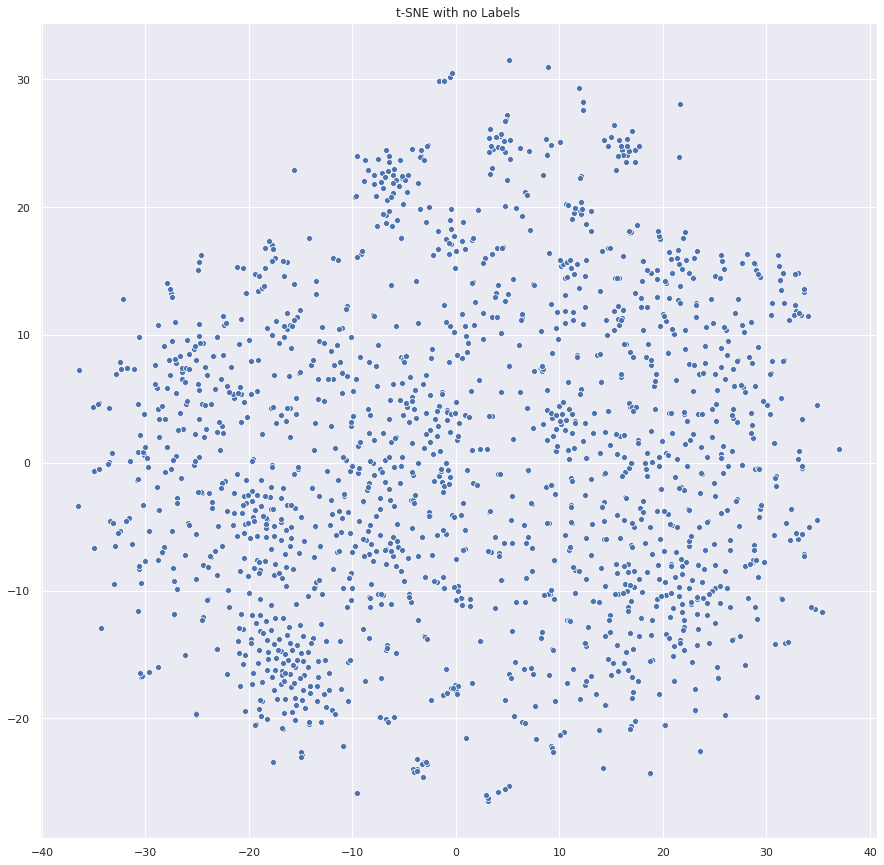

In [71]:
from matplotlib import pyplot as plt
import seaborn as sns

# sns settings
sns.set(rc={'figure.figsize':(15,15)})

# colors
palette = sns.color_palette("bright", 1)

# plot
sns.scatterplot(X_embedded[:,0], X_embedded[:,1], palette=palette)
plt.title('t-SNE with no Labels')
plt.savefig("t-sne_covid19.png")
plt.show()

This looks pretty bland. There are some clusters we can immediately detect, but the many instances closer to the center are harder to separate. t-SNE did a good job at reducing the dimensionality, but now we need some labels. Let's use the clusters found by k-means as labels. This will help visually separate different concentrations of topics.

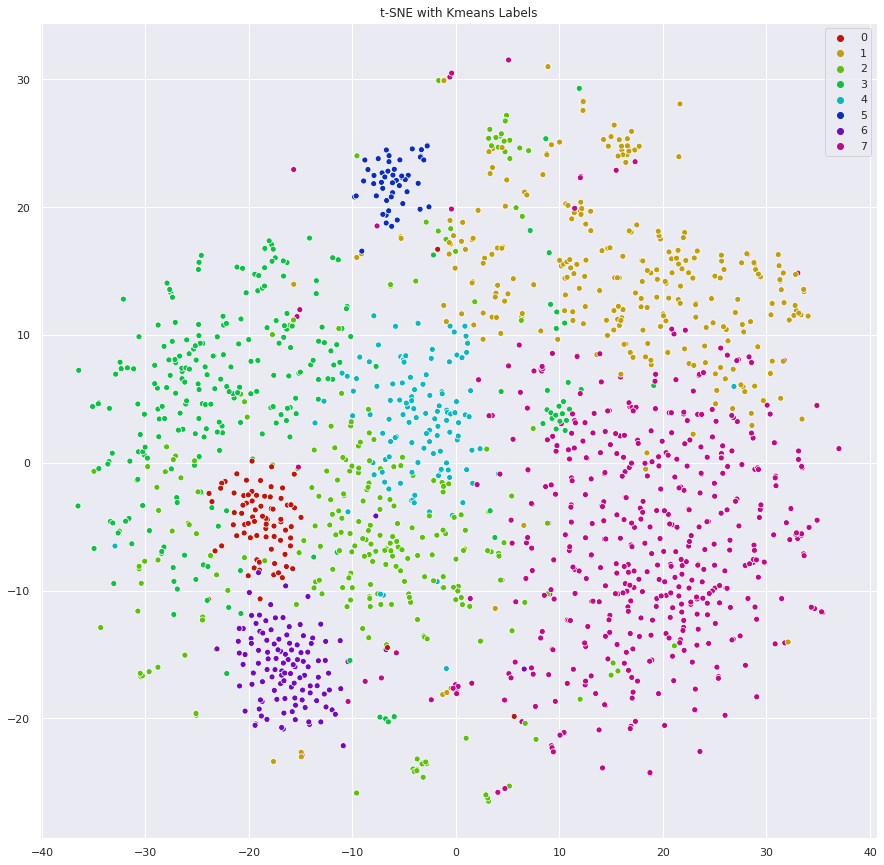

In [73]:
%matplotlib inline
from matplotlib import pyplot as plt
import seaborn as sns

# sns settings
sns.set(rc={'figure.figsize':(15,15)})

# colors
palette = sns.hls_palette(8, l=.4, s=.9)

# plot
sns.scatterplot(X_embedded[:,0], X_embedded[:,1], hue=y_pred, legend='full', palette=palette)
plt.title('t-SNE with Kmeans Labels')
plt.savefig("improved_cluster_tsne.png")
plt.show()

The labeled plot gives better insight into how the papers are grouped. It is interesting that both k-means and t-SNE are able to agree on certain clusters even though they were ran independetly. The location of each paper on the plot was determined by t-SNE while the label (color) was determined by k-means. If we look at a particular part of the plot where t-SNE has grouped many articles forming a cluster, it is likely that k-means is uniform in the labeling of this cluster (most of the cluster is the same color). This behavior shows that structure within the literature can be observed and measured to some extent. 

Now there are other cases where the colored labels (k-means) are spread out on the plot (t-SNE). This is a result of t-SNE and k-means finding different connections in the higher dimensional data. The topics of these papers often intersect so it hard to cleanly separate them. This effect can be observed in the formation of subclusters on the plot. These subclusters are a conglomeration of different k-means labels but may share some connection determined by t-SNE.

This organization of the data does not act as a simple search engine. The clustering + dimensionality reduction is performed on the mathematical similarities of the publications. As an unsupervised approach, the algorithms may even find connections that were unnaparent to humans. This may highlight hidden shared information and advance further research.


# Topic Modeling on Each Cluster

Now we will attempt to find the most significant words in each clusters. K-means clustered the articles but did not label the topics. Through topic modeling we will find out what the most important terms for each cluster are. This will add more meaning to the cluster by giving keywords to quickly identify the themes of the cluster.

For topic modeling, we will use LDA (Latent Dirichlet Allocation). In LDA, each document can be described by a distribution of topics and each topic can be described by a distribution of words[.](https://towardsdatascience.com/light-on-math-machine-learning-intuitive-guide-to-latent-dirichlet-allocation-437c81220158)

In [0]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

In [0]:
Image(filename='/kaggle/input/kaggle-resources/lda.jpg', width=600, height=600)

[source](https://towardsdatascience.com/latent-dirichlet-allocation-15800c852699)

First we will create 20 vectorizers, one for each of our cluster labels

In [0]:
vectorizers = []
    
for ii in range(0, 8):
    # Creating a vectorizer
    vectorizers.append(CountVectorizer(min_df=5, max_df=0.9, stop_words='english', lowercase=True, token_pattern='[a-zA-Z\-][a-zA-Z\-]{2,}'))

In [79]:
vectorizers[0]

CountVectorizer(analyzer='word', binary=False, decode_error='strict',
                dtype=<class 'numpy.int64'>, encoding='utf-8', input='content',
                lowercase=True, max_df=0.9, max_features=None, min_df=5,
                ngram_range=(1, 1), preprocessor=None, stop_words='english',
                strip_accents=None, token_pattern='[a-zA-Z\\-][a-zA-Z\\-]{2,}',
                tokenizer=None, vocabulary=None)

Now we will vectorize the data from each of our clusters

In [0]:
vectorized_data = []

for current_cluster, cvec in enumerate(vectorizers):
    try:
        vectorized_data.append(cvec.fit_transform(df.loc[df['y'] == current_cluster, 'processed_text']))
    except Exception as e:
        print("Not enough instances in cluster: " + str(current_cluster))
        vectorized_data.append(None)

In [81]:
len(vectorized_data)

8

Topic modeling will be performed through the use of Latent Dirichlet Allocation (LDA). This is a generative statistical model that allows sets of words to be explained by a shared topic

In [84]:
# number of topics per cluster
NUM_TOPICS_PER_CLUSTER = 20

lda_models = []
for ii in range(0, 8):
    # Latent Dirichlet Allocation Model
    lda = LatentDirichletAllocation(n_components=NUM_TOPICS_PER_CLUSTER, max_iter=10, learning_method='online',verbose=False, random_state=42)
    lda_models.append(lda)
    
lda_models[0]

LatentDirichletAllocation(batch_size=128, doc_topic_prior=None,
                          evaluate_every=-1, learning_decay=0.7,
                          learning_method='online', learning_offset=10.0,
                          max_doc_update_iter=100, max_iter=10,
                          mean_change_tol=0.001, n_components=20, n_jobs=None,
                          perp_tol=0.1, random_state=42, topic_word_prior=None,
                          total_samples=1000000.0, verbose=False)

For each cluster, we had created a correspoding LDA model in the previous step. We will now fit_transform all the LDA models on their respective cluster vectors

In [0]:
clusters_lda_data = []

for current_cluster, lda in enumerate(lda_models):
    # print("Current Cluster: " + str(current_cluster))
    
    if vectorized_data[current_cluster] != None:
        clusters_lda_data.append((lda.fit_transform(vectorized_data[current_cluster])))

Extracts the keywords from each cluster

In [0]:
# Functions for printing keywords for each topic
def selected_topics(model, vectorizer, top_n=3):
    current_words = []
    keywords = []
    
    for idx, topic in enumerate(model.components_):
        words = [(vectorizer.get_feature_names()[i], topic[i]) for i in topic.argsort()[:-top_n - 1:-1]]
        for word in words:
            if word[0] not in current_words:
                keywords.append(word)
                current_words.append(word[0])
                
    keywords.sort(key = lambda x: x[1])  
    keywords.reverse()
    return_values = []
    for ii in keywords:
        return_values.append(ii[0])
    return return_values

Append list of keywords for a single cluster to 2D list of length NUM_TOPICS_PER_CLUSTER

In [0]:
all_keywords = []
for current_vectorizer, lda in enumerate(lda_models):
    # print("Current Cluster: " + str(current_vectorizer))

    if vectorized_data[current_vectorizer] != None:
        all_keywords.append(selected_topics(lda, vectorizers[current_vectorizer]))

In [88]:
all_keywords[3]

['public',
 'water',
 'hiv',
 'study',
 'china',
 'case',
 'model',
 'human',
 'aids',
 'datum',
 'worker',
 'hand',
 'network',
 'knowledge',
 'age',
 'traveler',
 'group',
 'student',
 'indoor',
 'mental',
 'problem',
 'learn',
 'risk',
 'identity',
 'diabetes',
 'flu',
 'cancer',
 'pandemic',
 'article',
 'suicide',
 'participant',
 'disinfection',
 'antibiotic',
 'saudi',
 'disinfectant',
 'air',
 'quarantine',
 'disease',
 'vaccine',
 'influenza',
 'virus',
 'hygiene']

In [89]:
len(all_keywords)

8

### Save current outputs to file

Re-running some parts of the notebook (especially vectorization and t-SNE) are time intensive tasks. We want to make sure that the important outputs for generating the bokeh plot are saved for future use.

In [0]:
f=open('topics.txt','w')

count = 0

for ii in all_keywords:

    if vectorized_data[count] != None:
        f.write(', '.join(ii) + "\n")
    else:
        f.write("Not enough instances to be determined. \n")
        f.write(', '.join(ii) + "\n")
    count += 1

f.close()

In [0]:
import pickle

# save the COVID-19 DataFrame, too large for github
pickle.dump(df, open("df_covid.p", "wb" ))

# save the final t-SNE
pickle.dump(X_embedded, open("X_embedded.p", "wb" ))

# save the labels generate with k-means(20)
pickle.dump(y_pred, open("y_pred.p", "wb" ))

# Classify

Though arbitrary, after running kmeans, the data is now 'labeled'. This means that we now use supervised learning to see how well the clustering generalizes. This is just one way to evaluate the clustering. If k-means was able to find a meaningful split in the data, it should be possible to train a classifier to predict which cluster a given instance should belong to. 

In [0]:
# function to print out classification model report
def classification_report(model_name, test, pred):
    from sklearn.metrics import precision_score, recall_score
    from sklearn.metrics import accuracy_score
    from sklearn.metrics import f1_score
    
    print(model_name, ":\n")
    print("Accuracy Score: ", '{:,.3f}'.format(float(accuracy_score(test, pred)) * 100), "%")
    print("     Precision: ", '{:,.3f}'.format(float(precision_score(test, pred, average='macro')) * 100), "%")
    print("        Recall: ", '{:,.3f}'.format(float(recall_score(test, pred, average='macro')) * 100), "%")
    print("      F1 score: ", '{:,.3f}'.format(float(f1_score(test, pred, average='macro')) * 100), "%")

Let's split the data into train/test sets

In [91]:
from sklearn.model_selection import train_test_split

# test set size of 20% of the data and the random seed 42 <3
X_train, X_test, y_train, y_test = train_test_split(X.toarray(),y_pred, test_size=0.2, random_state=42)

print("X_train size:", len(X_train))
print("X_test size:", len(X_test), "\n")

X_train size: 1364
X_test size: 341 



**Precision** is ratio of True Positives to True Positives + False Positives. This is the accuracy of positive predictions<br>
**Recall** (also known as TPR) measures the ratio of True Positives to True Positives + False Negatives. It measures the ratio of positive instances that are correctly detected by the classifer.<br>
**F1 score**  is the harmonic average of the precision and recall. F1 score will only be high if both precision and recall are high

#### Cite: [Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow: Second Edition | Aurélien Geron](https://github.com/ageron/handson-ml2) 

In [92]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import SGDClassifier

# SGD instance
sgd_clf = SGDClassifier(max_iter=10000, tol=1e-3, random_state=42, n_jobs=4)
# train SGD
sgd_clf.fit(X_train, y_train)

# cross validation predictions
sgd_pred = cross_val_predict(sgd_clf, X_train, y_train, cv=3, n_jobs=4)

# print out the classification report
classification_report("Stochastic Gradient Descent Report (Training Set)", y_train, sgd_pred)

Stochastic Gradient Descent Report (Training Set) :

Accuracy Score:  92.742 %
     Precision:  93.750 %
        Recall:  92.546 %
      F1 score:  93.074 %


To test for overfitting, let's see how the model generalizes over the test set

In [93]:
# cross validation predictions
sgd_pred = cross_val_predict(sgd_clf, X_test, y_test, cv=3, n_jobs=4)

# print out the classification report
classification_report("Stochastic Gradient Descent Report (Training Set)", y_test, sgd_pred)

Stochastic Gradient Descent Report (Training Set) :

Accuracy Score:  90.323 %
     Precision:  93.719 %
        Recall:  90.838 %
      F1 score:  92.111 %


Now let's see how the model can generalize across the whole dataset.

In [94]:
sgd_cv_score = cross_val_score(sgd_clf, X.toarray(), y_pred, cv=10)
print("Mean cv Score - SGD: {:,.3f}".format(float(sgd_cv_score.mean()) * 100), "%")

Mean cv Score - SGD: 94.605 %


# Plotting the data
The previous steps have given us clustering labels and a dataset of papers reduced to two dimensions. By pairing this with Bokeh, we can create an interactive plot of the literature. This should organize the papers such that related publications are in close proximity. To try to undertstand what the similarities may be, we have also performed topic modelling on each cluster of papers in order to pick out the key terms.

Bokeh will pair the actual papers with their positions on the t-SNE plot. Through this approach it will be easier to see how papers fit together, allowing for both exploration of the dataset and evaluation of the clustering. 

In [0]:
import os

# change into lib directory to load plot python scripts
main_path = os.getcwd()
os.chdir(main_path)

In [0]:
# required libraries for plot
from call_backs import input_callback, selected_code  # file with customJS callbacks for bokeh
                                                      # github.com/MaksimEkin/COVID19-Literature-Clustering/blob/master/lib/call_backs.py
import bokeh
from bokeh.models import ColumnDataSource, HoverTool, LinearColorMapper, CustomJS, Slider, TapTool, TextInput
from bokeh.palettes import Category20
from bokeh.transform import linear_cmap, transform
from bokeh.io import output_file, show, output_notebook
from bokeh.plotting import figure
from bokeh.models import RadioButtonGroup, TextInput, Div, Paragraph
from bokeh.layouts import column, widgetbox, row, layout
from bokeh.layouts import column

## Load the Keywords per Cluster

In [0]:
import os

topic_path = 'topics.txt'
with open(topic_path) as f:
    topics = f.readlines()

## Setup

In [0]:
# show on notebook
output_notebook()
# target labels
y_labels = y_pred

# data sources
source = ColumnDataSource(data=dict(
    x= X_embedded[:,0], 
    y= X_embedded[:,1],
    x_backup = X_embedded[:,0],
    y_backup = X_embedded[:,1],
    desc= y_labels, 
    titles= df['title'],
    authors = df['authors'],
    journal = df['journal'],
    abstract = df['abstract_summary'],
    labels = ["C-" + str(x) for x in y_labels],
    links = df['doi']
    ))

# hover over information
hover = HoverTool(tooltips=[
    ("Title", "@titles{safe}"),
    ("Author(s)", "@authors{safe}"),
    ("Journal", "@journal"),
    ("Abstract", "@abstract{safe}"),
    ("Link", "@links")
],
point_policy="follow_mouse")

# map colors
mapper = linear_cmap(field_name='desc', 
                     palette=Category20[20],
                     low=min(y_labels) ,high=max(y_labels))

# prepare the figure
plot = figure(plot_width=1200, plot_height=850, 
           tools=[hover, 'pan', 'wheel_zoom', 'box_zoom', 'reset', 'save', 'tap'], 
           title="Clustering of the COVID-19 Literature with t-SNE and K-Means", 
           toolbar_location="above")

# plot settings
plot.scatter('x', 'y', size=5, 
          source=source,
          fill_color=mapper,
          line_alpha=0.3,
          line_color="black",
          legend = 'labels')
plot.legend.background_fill_alpha = 0.6

## Widgets

In [0]:
# Keywords
text_banner = Paragraph(text= 'Keywords: Slide to specific cluster to see the keywords.', height=45)
input_callback_1 = input_callback(plot, source, text_banner, topics)

# currently selected article
div_curr = Div(text="""Click on a plot to see the link to the article.""",height=150)
callback_selected = CustomJS(args=dict(source=source, current_selection=div_curr), code=selected_code())
taptool = plot.select(type=TapTool)
taptool.callback = callback_selected

# WIDGETS
slider = Slider(start=0, end=20, value=20, step=1, title="Cluster #", callback=input_callback_1)
keyword = TextInput(title="Search:", callback=input_callback_1)

# pass call back arguments
input_callback_1.args["text"] = keyword
input_callback_1.args["slider"] = slider

## Style

In [0]:
# STYLE
slider.sizing_mode = "stretch_width"
slider.margin=15

keyword.sizing_mode = "scale_both"
keyword.margin=15

div_curr.style={'color': '#BF0A30', 'font-family': 'Helvetica Neue, Helvetica, Arial, sans-serif;', 'font-size': '1.1em'}
div_curr.sizing_mode = "scale_both"
div_curr.margin = 20

text_banner.style={'color': '#0269A4', 'font-family': 'Helvetica Neue, Helvetica, Arial, sans-serif;', 'font-size': '1.1em'}
text_banner.sizing_mode = "scale_both"
text_banner.margin = 20

plot.sizing_mode = "scale_both"
plot.margin = 5

r = row(div_curr,text_banner)
r.sizing_mode = "stretch_width"

## SHOW

In [0]:
# LAYOUT OF THE PAGE
l = layout([
    [slider, keyword],
    [text_banner],
    [div_curr],
    [plot],
])
l.sizing_mode = "scale_both"

# show
output_file('t-sne_covid-19_interactive.html')
show(l)